# CEI Internship Program 2026 — Week 6 Assignment
Author: Sankalp Tamboli:

# Autoencoder MNIST

## Importing required packages

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

In [25]:
np.random.seed(42)
torch.manual_seed(42)

## Defining transforms

In [26]:
transforms=transforms.ToTensor()

## Downloading requried data

In [27]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

## Defining dataloaders

In [28]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [29]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [30]:
# checking our data
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [31]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

## Visualizing a Training batch

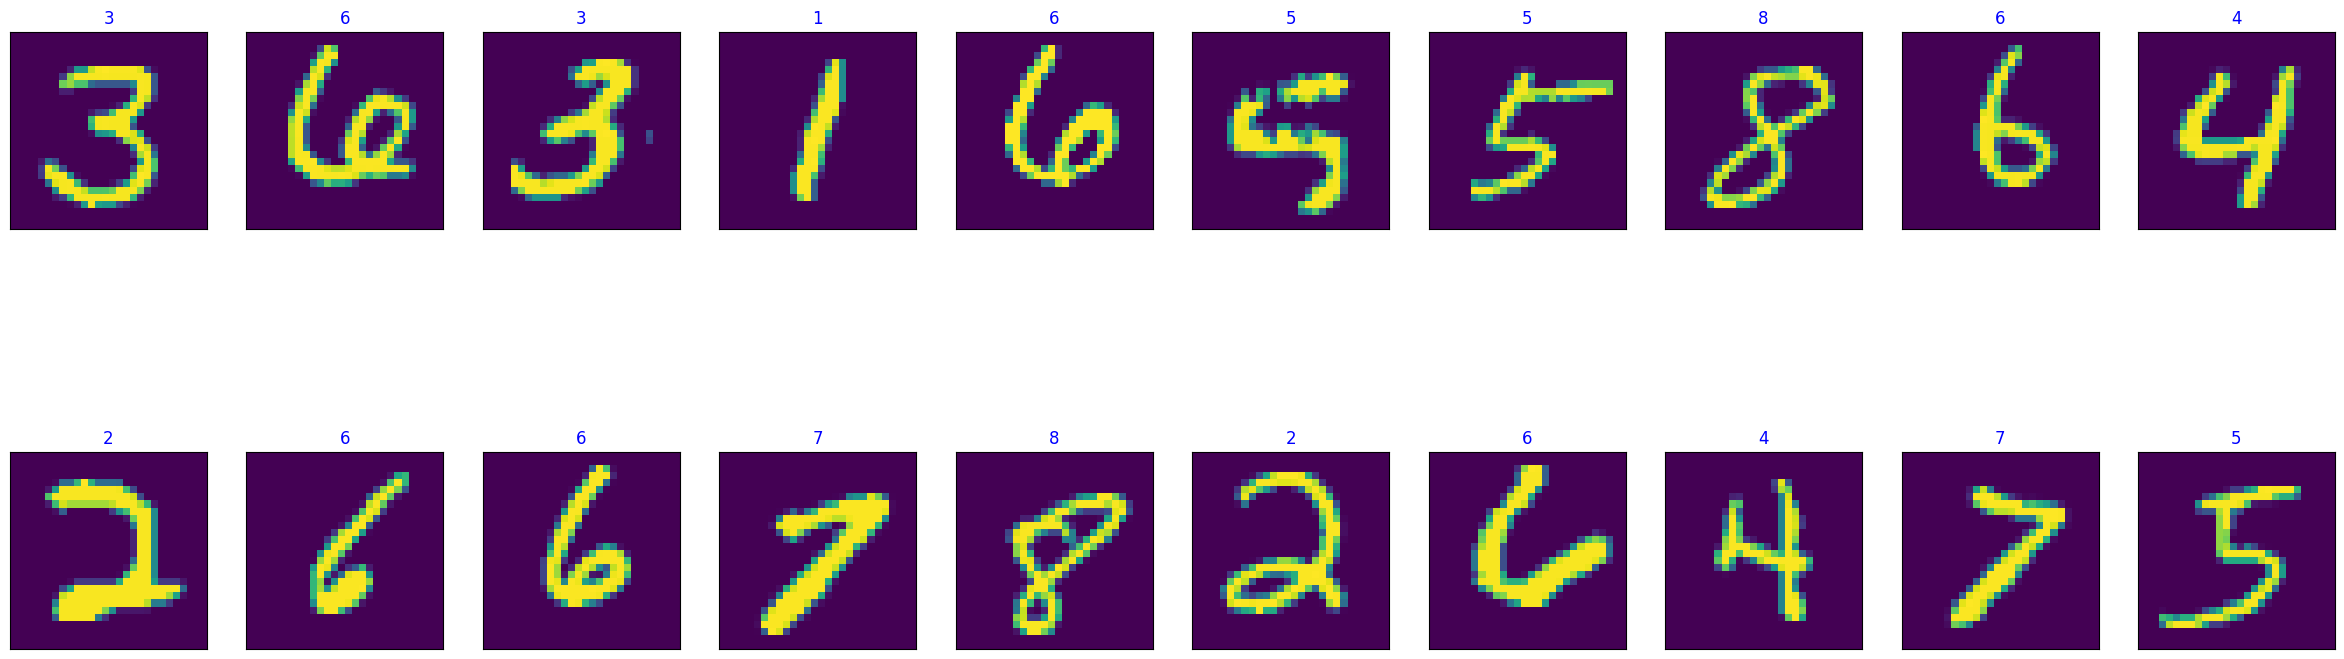

In [32]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [33]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, en_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(en_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=torch.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=torch.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [35]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

model_1 = model_1.to(device)
model_2 = model_2.to(device)
model_3 = model_3.to(device)
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): 

## Defining our Loss Function

In [36]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [37]:
def trainNet(model, lr, state='fully'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_keeper = {'train': [], 'valid': []}
    epochs = 20
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images)
            if state == 'fully':
                images = images.view(images.size(0), -1)
                noisy_images = noisy_images.view(noisy_images.size(0), -1)  # <-- fix
            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criterion(output, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
          for images, _ in valid_loader:
              images = images.to(device)
              noisy_images = add_noise(images)
              if state == 'fully':
                  images = images.view(images.size(0), -1)
                  noisy_images = noisy_images.view(noisy_images.size(0), -1)  # <-- fix
              output = model(noisy_images)
              loss = criterion(output, images)
              valid_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        valid_loss = valid_loss / len(valid_loader)
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss <= valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z = type(model).__name__
            torch.save(model.state_dict(), z + '_model.pth')
            valid_loss_min = valid_loss

    return loss_keeper

In [38]:
m1_loss=trainNet(model_1,0.001)


Epoch : 1	Training Loss : 0.03308853637039041	Validation Loss : 0.02611436361446977
Validation loss decreased from : inf ----> 0.02611436361446977 ----> Saving Model.......

Epoch : 2	Training Loss : 0.024592641030903906	Validation Loss : 0.023632077161843578
Validation loss decreased from : 0.02611436361446977 ----> 0.023632077161843578 ----> Saving Model.......

Epoch : 3	Training Loss : 0.02278334749901357	Validation Loss : 0.022155713212365907
Validation loss decreased from : 0.023632077161843578 ----> 0.022155713212365907 ----> Saving Model.......

Epoch : 4	Training Loss : 0.021659055184184883	Validation Loss : 0.02122869827163716
Validation loss decreased from : 0.022155713212365907 ----> 0.02122869827163716 ----> Saving Model.......

Epoch : 5	Training Loss : 0.02071660925207349	Validation Loss : 0.020650983834639192
Validation loss decreased from : 0.02122869827163716 ----> 0.020650983834639192 ----> Saving Model.......

Epoch : 6	Training Loss : 0.020011442210525275	Validati

In [39]:
m2_loss=trainNet(model_2,0.001,'conv')


Epoch : 1	Training Loss : 0.04159110158138598	Validation Loss : 0.02650664961275955
Validation loss decreased from : inf ----> 0.02650664961275955 ----> Saving Model.......

Epoch : 2	Training Loss : 0.025816023454535753	Validation Loss : 0.02540446994515757
Validation loss decreased from : 0.02650664961275955 ----> 0.02540446994515757 ----> Saving Model.......

Epoch : 3	Training Loss : 0.024909280970847856	Validation Loss : 0.024536082781851293
Validation loss decreased from : 0.02540446994515757 ----> 0.024536082781851293 ----> Saving Model.......

Epoch : 4	Training Loss : 0.02420154716897135	Validation Loss : 0.02379458071043094
Validation loss decreased from : 0.024536082781851293 ----> 0.02379458071043094 ----> Saving Model.......

Epoch : 5	Training Loss : 0.023235022323206067	Validation Loss : 0.02284499888929228
Validation loss decreased from : 0.02379458071043094 ----> 0.02284499888929228 ----> Saving Model.......

Epoch : 6	Training Loss : 0.022417098599641274	Validation L

In [40]:
m3_loss=trainNet(model_3,0.001,'conv')


Epoch : 1	Training Loss : 0.053044982734136284	Validation Loss : 0.03650309239203731
Validation loss decreased from : inf ----> 0.03650309239203731 ----> Saving Model.......

Epoch : 2	Training Loss : 0.035723667259638506	Validation Loss : 0.03528111823213597
Validation loss decreased from : 0.03650309239203731 ----> 0.03528111823213597 ----> Saving Model.......

Epoch : 3	Training Loss : 0.03454149727399151	Validation Loss : 0.03391390021579961
Validation loss decreased from : 0.03528111823213597 ----> 0.03391390021579961 ----> Saving Model.......

Epoch : 4	Training Loss : 0.033620302135435244	Validation Loss : 0.03312404322748383
Validation loss decreased from : 0.03391390021579961 ----> 0.03312404322748383 ----> Saving Model.......

Epoch : 5	Training Loss : 0.03295063765021041	Validation Loss : 0.032618484801302354
Validation loss decreased from : 0.03312404322748383 ----> 0.032618484801302354 ----> Saving Model.......

Epoch : 6	Training Loss : 0.03246853163465858	Validation Los

In [41]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth',map_location = device))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth',map_location=device))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth',map_location=device))

<All keys matched successfully>

## Plotting Loss

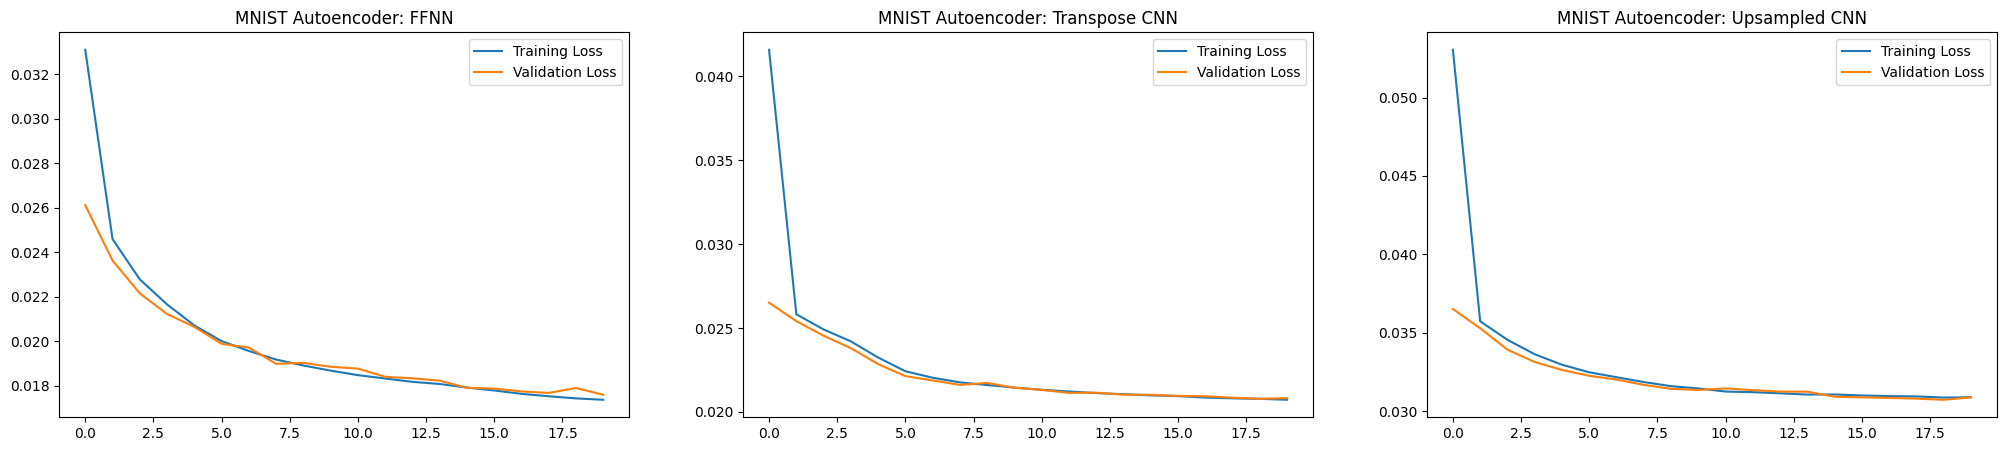

In [42]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [43]:
def test(model, state='fully'):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    noisy_images = add_noise(images)

    images = images.to(device)
    noisy_images = noisy_images.to(device)

    if state == 'fully':
        noisy_input = noisy_images.view(noisy_images.size(0), -1)
    else:
        noisy_input = noisy_images

    output = model(noisy_input)

    # prep for display
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    output = output.view(batch_size, 1, 28, 28).cpu().detach().numpy()

    mse = np.mean((output - images) ** 2)
    print(f"Test Batch MSE: {mse:.6f}")
    # 3-row plot: original / noisy / denoised
    fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(25, 6))
    for i in range(10):
        axes[0, i].imshow(np.squeeze(images[i]), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(np.squeeze(noisy_images[i]), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(np.squeeze(output[i]), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_title('Original', loc='left', fontsize=12)
    axes[1, 0].set_title('Noisy', loc='left', fontsize=12)
    axes[2, 0].set_title('Denoised', loc='left', fontsize=12)
    plt.tight_layout()
    plt.show()

## FFNN Autoencoder

Test Batch MSE: 0.015882


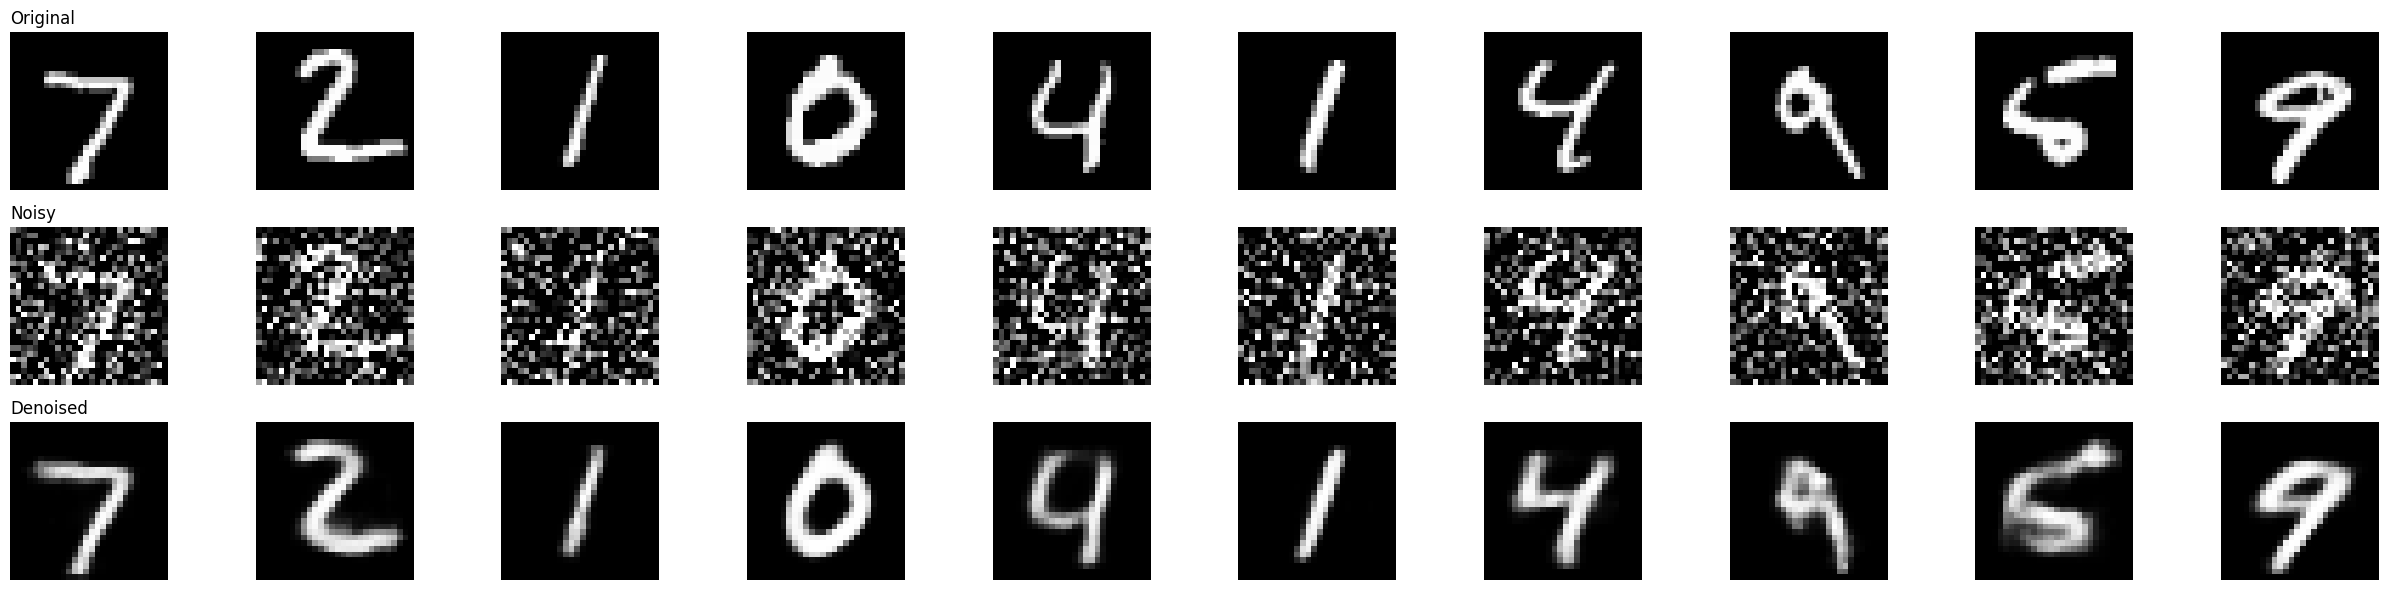

In [44]:
test(model_1)

## Transpose CNN Autoencoder

Test Batch MSE: 0.019820


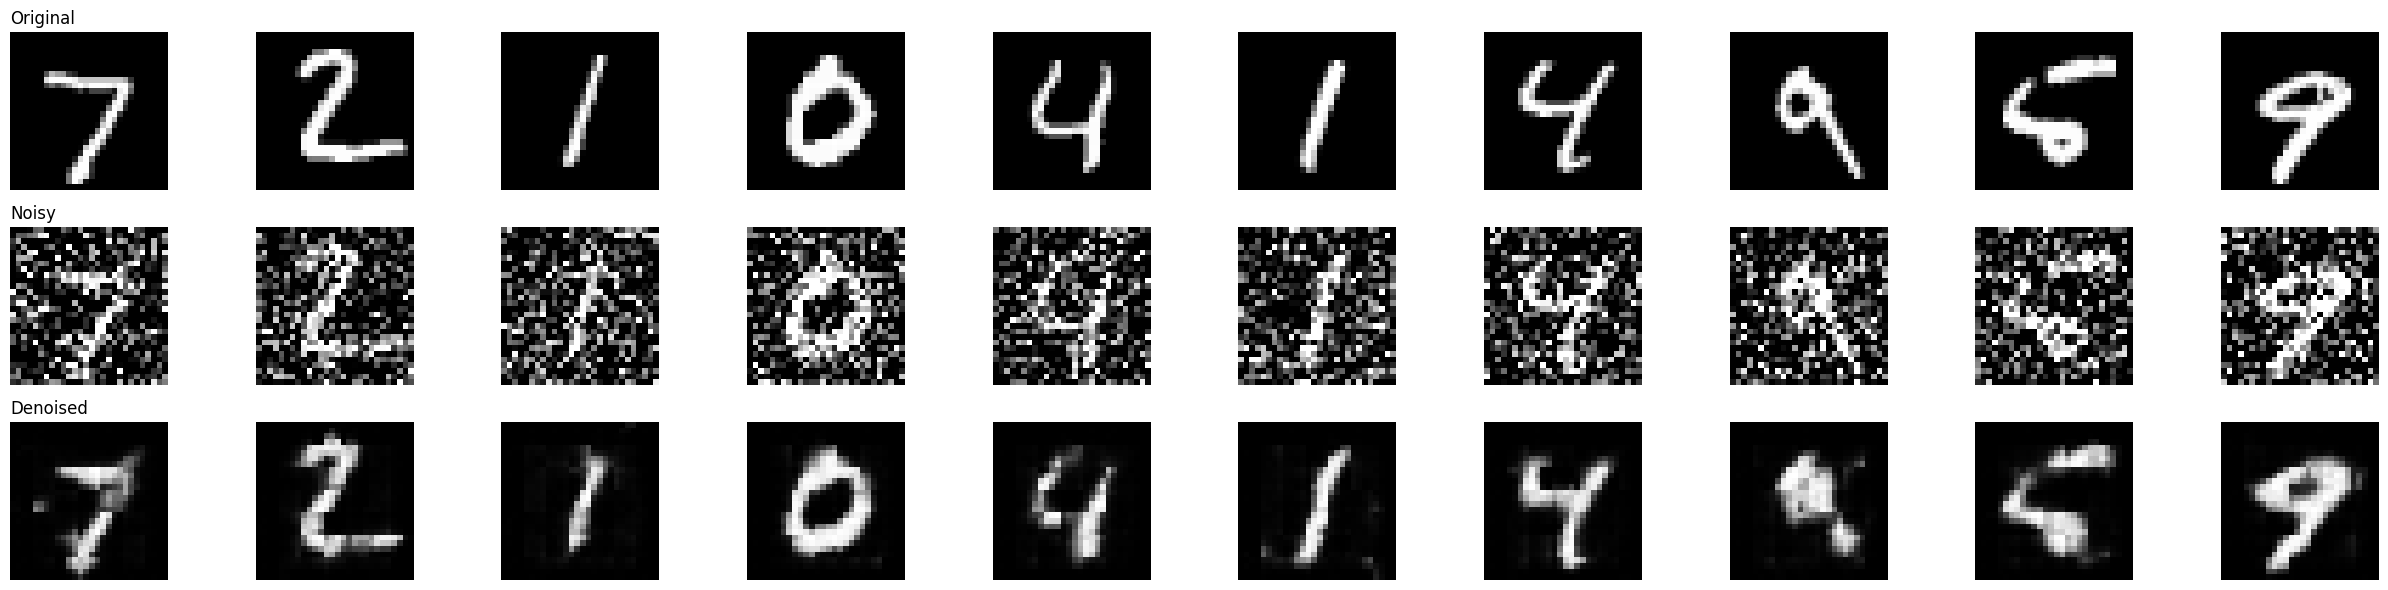

In [45]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

Test Batch MSE: 0.029192


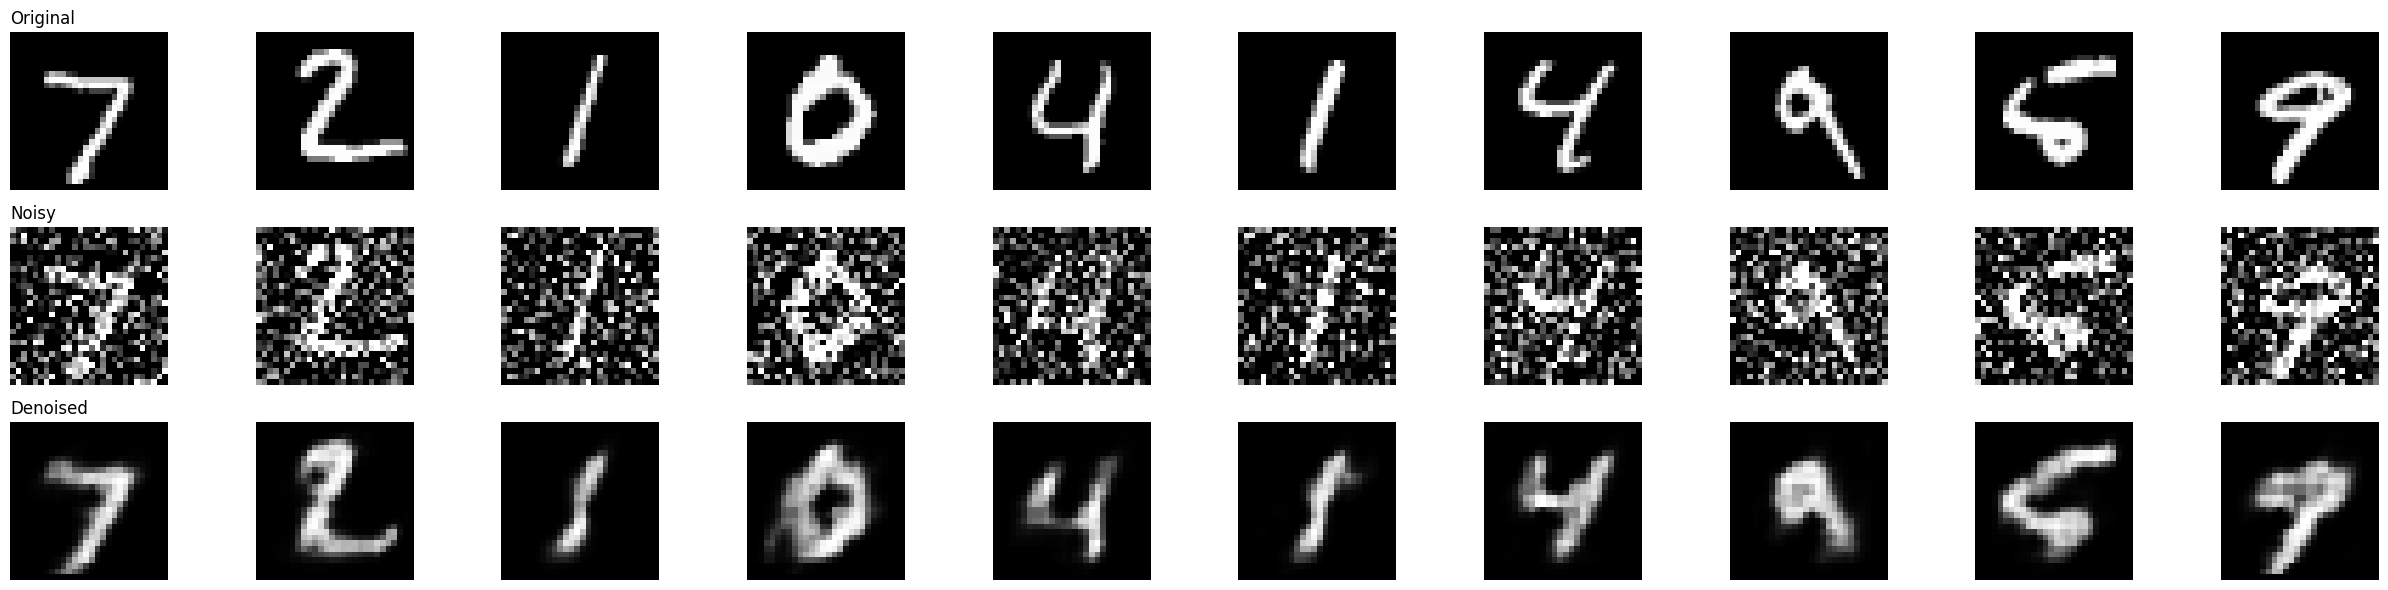

In [46]:
test(model_3,'conv')

## 📝 Observations and Analysis

### 📊 Results Summary

| Model | Architecture | Final Train Loss | Final Val Loss | Test MSE |
|-------|-------------|-----------------|----------------|----------|
| Model 1 | Fully-Connected (FFNN) | 0.017378 | 0.017605 | 0.015882 ✅ Best |
| Model 2 | Transpose CNN | 0.020716 | 0.020814 | 0.019820 |
| Model 3 | Upsampled CNN | 0.030875 | 0.030866 | 0.029192 |

---

### 🏗️ Architecture Insights

- **FFNN Autoencoder:** Flattens 28×28 images into 784-dim vectors, compresses to a 32-dim bottleneck through 2 encoder layers (784→256→32), then reconstructs through 2 decoder layers (32→256→784). Achieved the best test MSE of 0.015882. Training loss dropped consistently from 0.033 → 0.017 across 20 epochs showing smooth convergence.

- **Transpose CNN:** Uses Conv2d + MaxPool for encoding (28×28 → 7×7) and ConvTranspose2d for decoding back to 28×28. Achieved test MSE of 0.019820. Training loss reduced from 0.041 → 0.020 — steady and healthy convergence throughout all 20 epochs.

- **Upsampled CNN:** Same encoder as Model 2, but uses nearest-neighbor interpolation + Conv layers in the decoder instead of ConvTranspose2d, avoiding checkerboard artifacts. Achieved test MSE of 0.029192. Training loss dropped from 0.053 → 0.030 across 20 epochs.

---

### 🔍 Key Observations

1. **FFNN achieved the best MSE (0.015882)** — for simple 28×28 grayscale MNIST images, the fully connected architecture with a 32-dim bottleneck converged the fastest and produced the sharpest reconstructions.

2. **All 3 models converged smoothly** — training and validation losses tracked closely across all 20 epochs with no signs of overfitting, confirming stable training.

3. **Model checkpointing worked effectively** — best weights were saved whenever validation loss improved, ensuring the final loaded model is the best version seen during training.

4. **CNN models showed higher MSE than FFNN** — this is because MNIST is a relatively simple dataset (28×28 grayscale). CNN spatial advantages become more evident on complex, high-resolution datasets.

5. **Noise factor = 0.5** created moderate Gaussian corruption. All three models successfully recovered the digit structure from noisy inputs, confirming the denoising objective was learned effectively.

---

### ⚠️ Challenges Faced

- **FFNN shape mismatch:** Both noisy input and clean target had to be flattened consistently before computing MSE loss — mismatching shapes caused errors initially.
- **`torch.load()` compatibility:** Required `map_location=device` to avoid crashes when running on CPU-only environments.
- **ConvTranspose2d artifacts:** Can introduce checkerboard patterns at stride boundaries — Model 3 addressed this using interpolation-based upsampling instead.
- **Device handling:** Replaced all `.cuda()` calls with `.to(device)` to ensure the notebook runs on both GPU and CPU runtimes.

---

### ✅ Conclusion

All three denoising autoencoders successfully learned to remove Gaussian noise from MNIST digits. The FFNN achieved the best reconstruction quality (Test MSE: 0.015882), followed by Transpose CNN (0.019820) and Upsampled CNN (0.029192). While CNNs are generally preferred for image tasks due to their spatial inductive bias, the simplicity of MNIST allowed the FFNN to converge more effectively here. Training with more epochs, deeper CNN architectures, or higher noise factors would likely reveal stronger CNN advantages over the FFNN baseline.